# Deep Learning Portfolio

Cosima Baumeier, Winter Semester 25/26

Imports and global settings:

In [1]:
import pandas as pd
import os
import cv2 as cv
import numpy as np
import random
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score, precision_score, confusion_matrix
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.init as init
import torchvision
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
torch.set_default_dtype(torch.float)

#for reproducible results, this has to run before the experiments -> I always use "Run All" instead of re-running single cells
RANDOM_SEED = 1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PL_GLOBAL_SEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

pd.options.display.max_columns = None

## Task 1 - The Data

The data was obtained from the UC Irvine Machine Learning Repository under the following link: https://archive.ics.uci.edu/dataset/908/realwaste. The dataset is licenced under CC BY-NC-SA 4.0.
 
Citation: Single, S., Iranmanesh, S., & Raad, R. (2023). RealWaste [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5SS4G

It is an color image dataset with 524x524 resolution pictures of waste material received at the Whyte's Gully Waste and Resource Recovery facility in Wollongong NSW Australia. The images are already sorted into nine categories: Cardboard, Food Organics, Glass, Metal, Miscellaneous Trash, Paper, Plastic, Textile Trash and Vegetation. 

Since clear plastic has a significantly higher market price compared to colored plastics, I decided to further label the plastic waste into transparent and opaque plastic. I did the labelling manually in a csv file. The data assembly was done in the assembly.ipynb notebook. The assembled dataset contains the image filename, the label and the path to the image.

The dataset is suitable for the proposed task, because it reflects the actual conditions of waste at a waste recovery facility. The images are not "studio quality". The waste contains dirt, moisture, organic residues, etc. Also, the dataset contains multiple images of the same objects from different perspectives, enabeling a convolutional neural network to learn more robust, viewpoint-invariant features, leading to better generalization. 

### Reading in the data

Firsly, I read in the assembled waste dataset. Note that the dataset only contains the image name, the label and the path to the image. The actual image pixel data doesn't get stored in a Pandas dataframe but loaded and preprocessed in batches when they are needed during training. 

In [2]:
raw_data = pd.read_csv('assembled_waste_data.csv')

Here are some examples of the actual images, currently stored in folders on my computer:

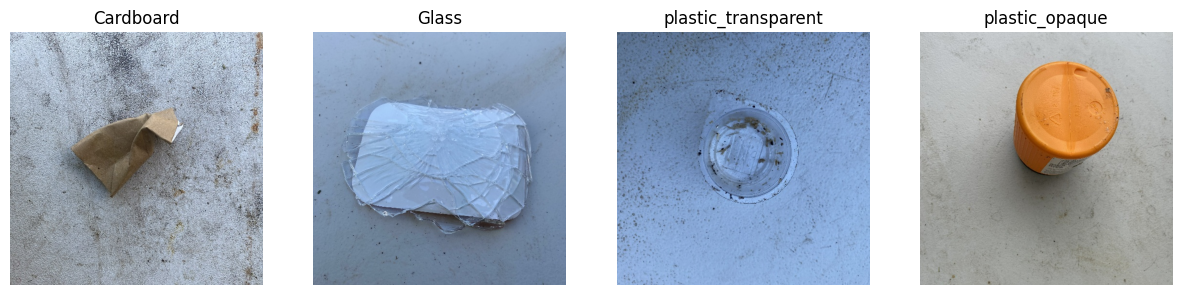

In [3]:
BASE_PATH = 'realwaste/realwaste-main/RealWaste/' #specifying the base path because there is only the relative path saved in the "path" columns
plt.figure(figsize=(15, 5))
example_categories = ['Cardboard', 'Glass', 'plastic_transparent', 'plastic_opaque']   
for i, category in enumerate(example_categories):
    img = cv.imread(os.path.join(BASE_PATH, raw_data[raw_data['label'] == category]['path'].iloc[2])) #getting the third image for each of my example categories
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB) #converting from BGR to RGB for matplolib
        
    plt.subplot(1, len(example_categories), i + 1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')
plt.show()

## Task 2 - Initial Data Analysis

In [4]:
raw_data.shape

(4752, 3)

There are 4752 rows in the dataset with an "image" column containing the image name, a "label" column with the name of the waste category and a "path" column with the path on my computer where the images are stored. This is how the data currently looks like:

In [5]:
raw_data.head()

,image,label,path
0,Cardboard_1.jpg,Cardboard,Cardboard\Cardboard_1.jpg
1,Cardboard_10.jpg,Cardboard,Cardboard\Cardboard_10.jpg
2,Cardboard_100.jpg,Cardboard,Cardboard\Cardboard_100.jpg
3,Cardboard_101.jpg,Cardboard,Cardboard\Cardboard_101.jpg
4,Cardboard_102.jpg,Cardboard,Cardboard\Cardboard_102.jpg


In [6]:
raw_data.isna().sum()

image    0
label    0
path     0
dtype: int64

There are no missing values. 

The following table shows the class distribution of the data:

In [7]:
raw_data['label'].value_counts().reset_index()

,label,count
0,Metal,790
1,Paper,500
2,Miscellaneous Trash,495
3,plastic_transparent,494
4,Cardboard,461
5,Vegetation,436
6,plastic_opaque,427
7,Glass,420
8,Food Organics,411
9,Textile Trash,318


The dataset is imbalanced. The 'Metal' category contains more than twice as many images (790) as the 'Textile Trash' category (318). The remaining categories have image counts ranging from 411 to 500. Subdividing the plastic waste into 'transparent' and 'opaque' categories helped to improve the class balance of the dataset.

## Task 3 - Preprocessing

Since the main preprocessing (resizing, converting to tensors, normalization) are integrated into the data loading pipeline and applied per batch during training, there isn't much preprocessing necessary before that. However, because PyTorch models require numerical inputs for the loss function, I performed label encoding on the categorical string labels. I named the new column "target". Every waste category now has its own number from 0 to 9. 

In [8]:
data = raw_data.copy() #copy of the raw data
unique_labels = sorted(data['label'].unique()) #finding the unique labels
label_numbers = {label: i for i, label in enumerate(unique_labels)} #one number for each unique label
data['target'] = data['label'].map(label_numbers) #new columns
pd.DataFrame(list(label_numbers.items()), columns=['Category', 'Target ID']) #shows every category next to the target ID

,Category,Target ID
0,Cardboard,0
1,Food Organics,1
2,Glass,2
3,Metal,3
4,Miscellaneous Trash,4
5,Paper,5
6,Textile Trash,6
7,Vegetation,7
8,plastic_opaque,8
9,plastic_transparent,9


This is how the data looks now:

In [9]:
data

,image,label,path,target
0,Cardboard_1.jpg,Cardboard,Cardboard\Cardboard_1.jpg,0
1,Cardboard_10.jpg,Cardboard,Cardboard\Cardboard_10.jpg,0
2,Cardboard_100.jpg,Cardboard,Cardboard\Cardboard_100.jpg,0
3,Cardboard_101.jpg,Cardboard,Cardboard\Cardboard_101.jpg,0
4,Cardboard_102.jpg,Cardboard,Cardboard\Cardboard_102.jpg,0
...,...,...,...,...
4747,Vegetation_95.jpg,Vegetation,Vegetation\Vegetation_95.jpg,7
4748,Vegetation_96.jpg,Vegetation,Vegetation\Vegetation_96.jpg,7
4749,Vegetation_97.jpg,Vegetation,Vegetation\Vegetation_97.jpg,7
4750,Vegetation_98.jpg,Vegetation,Vegetation\Vegetation_98.jpg,7


In [10]:
data.shape

(4752, 4)

It now has 4 columns and the same 4752 rows. 

## Task 4 - Exploratory Data Analysis

To get an overview over the data, I decided to look into pixel values of the images. For that, I loaded a subsample of 100 images per waste category and extracted the standard deviation of luminance, the edge density and the mean values of the color channels for every image. This, of course, doesn't reflect the whole dataset but I thought 100 images should representative. 

This is were I found out how to change color spaces: https://www.geeksforgeeks.org/python/python-opencv-cv2-cvtcolor-method/. OpenCV loads images in a BGR (blue, green, red) color space but visualizations with matplotlib require a RGB (red, green, blue) color space. To calculate the standard deviation of luminance and the edge density, the images needed to be converted into greyscale.

In [11]:
eda_data = [] #creating a list 

for label in data['label'].unique(): #loop performed for every waste category
    samples = data[data['label'] == label].sample(min(100, len(data[data['label'] == label])), random_state = RANDOM_SEED) #taking only a subsample of 100 images per category
    for _, row in samples.iterrows():
        img = cv.imread(os.path.join(BASE_PATH, row['path'])) #reading the images from the folders
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB) #converting them from BGR to RGB for matplotlib
        red_avg = img[:,:,0].mean() #mean of red channel values
        green_avg = img[:,:,1].mean() #mean of green channel values
        blue_avg = img[:,:,2].mean() #mean of blue channel values
            
        gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY) #converting to greyscale
        std_luminance = gray.std() #calculating the standard deviation of luminance

        edges = cv.Canny(gray, 100, 200) 
        edge_density = np.sum(edges > 0) / (524 * 524) #number of "true" pixels compared to all pixels -> explanation in text
            
        eda_data.append({
            'label': label,
            'std_luminance': std_luminance,
            'edge_density': edge_density,
            'red_avg': red_avg,
            'green_avg': green_avg,
            'blue_avg': blue_avg
        })

eda_df = pd.DataFrame(eda_data) #saving to a pandas dataframe


### 1. Insight: Image contrast per waste category

The standard deviation of luminance is a measure for the contrast in an image. Every pixel in a greyscale image has a value from 0 (black) to 255 (white). I calculated the average luminance of all pixels (the mean pixel value) in the image and then the standard deviation. When the standard deviation is high, it means that many pixels in the image are very different in brightness and the image therefore has a high contrast. When the standard deviation is low, the pixels have similar luminance values and the contrast is low. 

Here, I plotted boxplots for the standard deviation of luminance grouped by waste category. The boxes extend from the lower quartile of the data to the upper quartile of the data, so it contains the middle 50% of the data points (luminance standard deviation values), the line in the box represents the median. The lines extending from the ends of the box (whiskers) show the spread of the remaining data points, extending 1.5 times the interquartile range above and below. Points outside the lines are considered outliers.

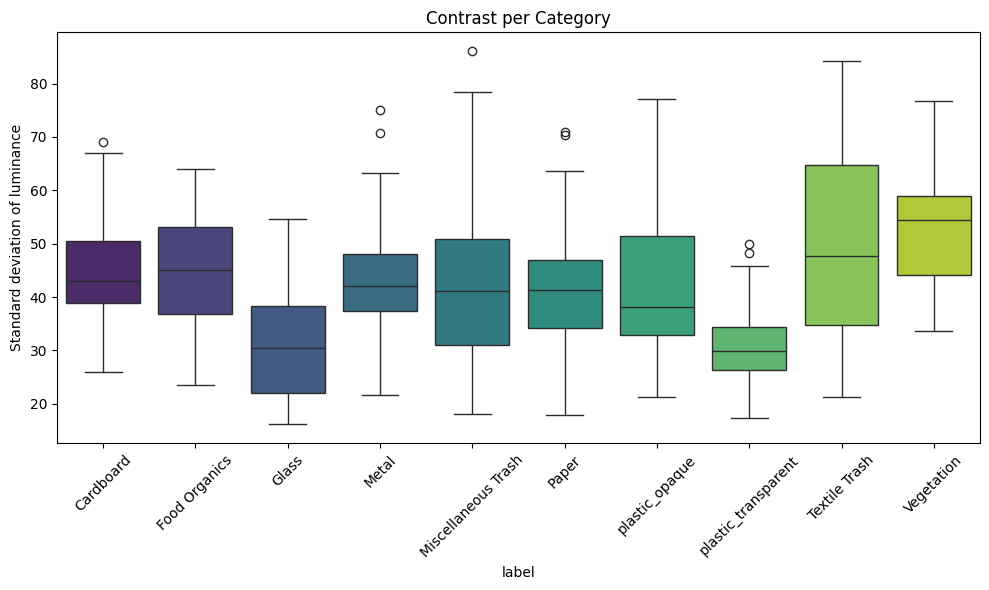

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='std_luminance', data=eda_df, palette='viridis', hue='label', legend=False)
plt.title('Contrast per Category')
plt.xticks(rotation=45)
plt.ylabel('Standard deviation of luminance')
plt.tight_layout()
plt.show()

What can you see in this plot is:
- Textile trash has the largest box with long whiskers -> images in this category are very different in contrast
- Opaque plastic images have a higher standard deviation of luminance than images of transparent plastic -> opaque plastic is, on average, higher in contrast than transparent plastic 
- Metal and transparent plastic images have a smaller box than the other categories -> the images within this categories don't differ much in contrast 
- Cardboard, food organics, metal, miscellaneous trash, paper, opaque plastic and textile trash all have comparable median values -> **image contrast alone isn't a good measure to differentiate between waste categories**

### 2. Insight: Image edge density per category

Image edge density is calculated with the canny edge detection algorithm (https://www.geeksforgeeks.org/python/python-opencv-canny-function/). It is used to identify edges within an image. You have to provide a lower threshold (in my case 100) and an upper threshold (in my case 200). The algorithm calculated the gradient of the image intensity. Where the gradient is high, there is a potential edge. The function returns an image where edges are marked in white and non-edges in black. Here is an example image:

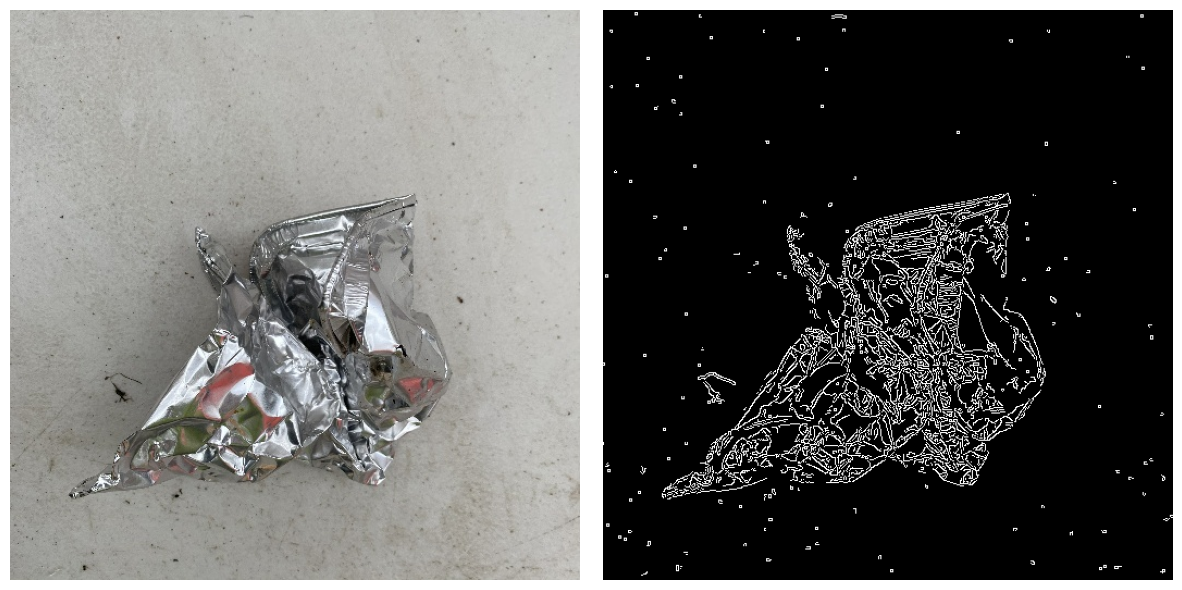

In [13]:
random_sample = data.sample(1, random_state=RANDOM_SEED).iloc[0]
example_img_path = os.path.join(BASE_PATH, random_sample['path'])
example_img_bgr = cv.imread(example_img_path)
example_img_rgb = cv.cvtColor(example_img_bgr, cv.COLOR_BGR2RGB)
example_img_gray = cv.cvtColor(example_img_rgb, cv.COLOR_RGB2GRAY)
example_img_edges = cv.Canny(example_img_gray, 100, 200)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(example_img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(example_img_edges, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

I suspected that some categories have a higher edge density than others because the waste has a more "complex" surface. Here is a plot of the edge densities grouped by category:

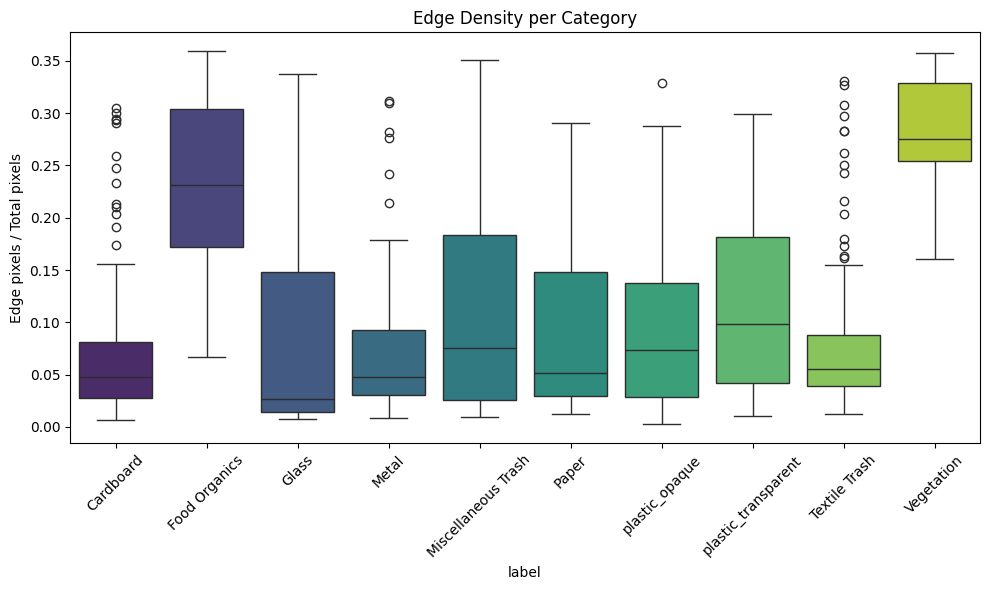

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='edge_density', data=eda_df, palette='viridis', hue='label', legend=False)
plt.title('Edge Density per Category')
plt.xticks(rotation=45)
plt.ylabel('Edge pixels / Total pixels')
plt.tight_layout()
plt.show()

What you can see in this plot is:
- Food organics and vegetation images have a much higher edge density -> more edges due to irregular shapes, shadows or surface textures (leaves, fibers)
- Cardboard, metal and textile trash images have the lowest edge density, although with many outliers -> surfaces are rather uniform
- The other categories have comparable values and long whiskers 
- **Edge density alone isn't a good measure to differentiate between waste categories, either**

### 3. Insight: RGB value means per category

Lastly, I looked at the mean color channel values in each waste category because I suspected there might be differences, e.g. that vegetation images have high green values whereas plastic or glass have higher blue values. Here is a plot of the mean values grouped by waste category. Note that the y-axis is not to scale.

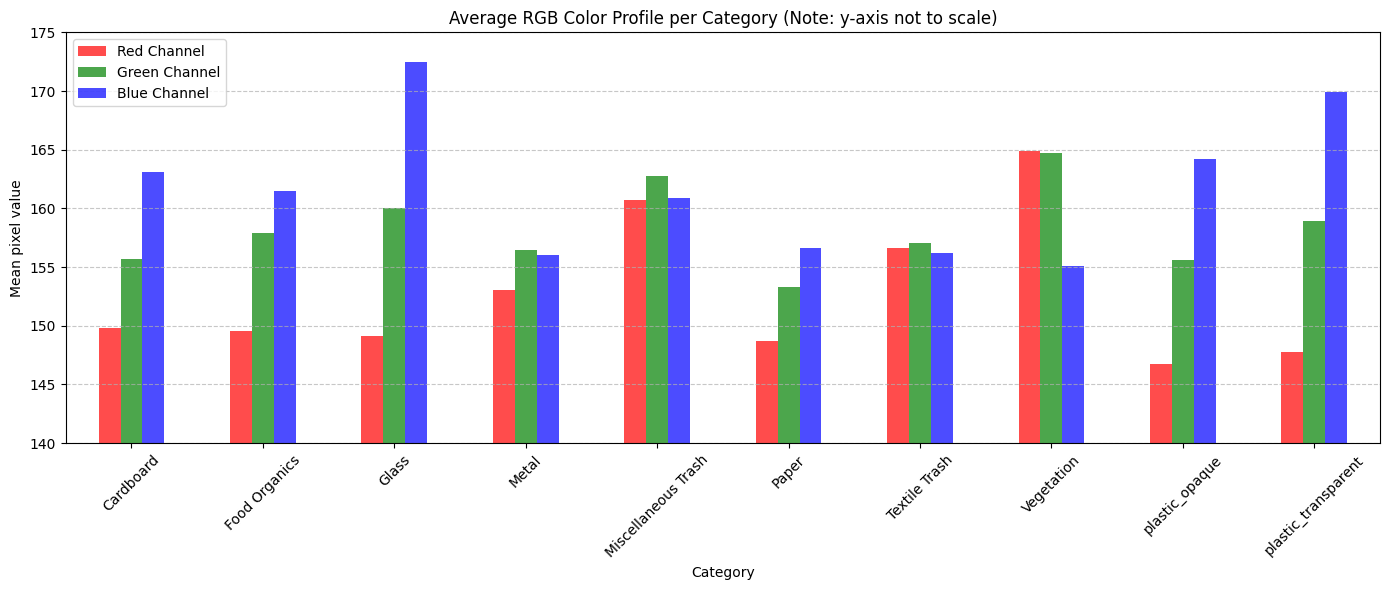

In [15]:
rgb_means = eda_df.groupby('label')[['red_avg', 'green_avg', 'blue_avg']].mean()

ax = rgb_means.plot(kind='bar', figsize=(14, 6), color=['red', 'green', 'blue'], alpha=0.7)
    
plt.title('Average RGB Color Profile per Category (Note: y-axis not to scale)')
plt.ylabel('Mean pixel value')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylim(140, 175)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(['Red Channel', 'Green Channel', 'Blue Channel'])
    
plt.tight_layout()
plt.show()

What you can see in this plot is:
- Glass and transparent have the highest values for the blue color channel, their green and especially red values are much lower -> "cool" color profile
- Vegetation has the highest red and green values and lower blue values -> "warm" color profile
- Opaque and transparent plastic aren't that different in their color channel values; transparent plastic has slightly higher green and blue values
- Within the categories metal, miscellaneous trash and textile trash, the color values are comparable for each channel -> there isn't a dominant color profile, the images couln't either contain many different colors or the images are very different
- **color channel values alone aren't a good measure to differentiate between waste categories, either** 

## Task 5 - Evaluation and Baseline

To evaluate a machine learning/ deep learning model, it's important to compute a baseline for evaluation metrics. The model has to, at least, outperform a simple heuristic. Otherwise, the model hasn't learned any useful information at all. As a heuristic, I chose stratified random guessing based on the class distribution of the dataset. For example, since the "Metal" category appears most frequently in my data, the baseline guesser predicts it more often.

For our use case at KWL, I chose balanced accuracy and precision for transparent plastic as evaluation metrics. 

Balanced accuracy is often used when the data is imbalanced, which is the case for my data. It is computed as the average of the recall obtained in each class. The recall is the number of correct positive predictions divided by the number of true positive instances. I chose balanced accuracy as a metric to evaluate the performance across all waste categories. 

Precision is the number of correct positive predictions divided by the number of positive predictions (true positive + false positive) made by the model. So for transparent plastic it represents the number of correctly classified transparent plastic images divided by the number of images classified as transparent plastic, including the wrong classifications. I chose this because for selling the plastic, it's important that it is "pure" and that no other waste is classified as transparent plastic. We would rather accept a lower recall (missing some transparent plastic) than a lower precision (contaminating the transparent plastic stream with other waste).

To evaluate, you need to split your data into training and testing data. The testing data gets held out of the training process to evaluate the model on independent data. If a model performs good on training data but bad on testing data, that means that the model has learned noise and specific details about the training data ("overfitting"). I chose a split of 80:20, so 80% of the images are used for training and 20% for testing.

In [16]:
df_train_val, df_test = train_test_split( #I named the train df like this to avoid confusion when I later split it into train and validation
    data,
    test_size=0.2,
    shuffle=True, #because my categories are ordered
    stratify=data["target"], #stratefied for the waste category
    random_state=RANDOM_SEED)

In [17]:
X_train = df_train_val["path"]   #doesn't matter for dummy classifier
y_train = df_train_val["label"]
X_test = df_test["path"]
y_test = df_test["label"]

In [18]:
dummy_clf = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_SEED)

dummy_clf.fit(X_train, y_train)


,strategy,'stratified'
,random_state,1
,constant,None


In [19]:
y_pred = dummy_clf.predict(X_test)

bac_dummy = balanced_accuracy_score(y_test, y_pred)
precisions_dummy = precision_score(y_test, y_pred, average=None, zero_division=0)
precision_trans_pl_dummy = precisions_dummy[9]
print(f"Baseline balanced accuracy: {bac_dummy:.4f}")
print(f"Baseline precision transparent plastic: {precision_trans_pl_dummy:.4f}")


Baseline balanced accuracy: 0.1034
Baseline precision transparent plastic: 0.1263


The baseline for balanced accuracy is 0.1034, which is consistent with the theoretical probability of a 10-class classification problem (1/10 = 0.10). The Precision for transparent plastic reached only 0.1263, highlighting that blind guessing would result in a highly contaminated waste stream with nearly 87% incorrect classifications.

## Task 6 - Deep Learning Experiments

I selected a Convolutional Neural Network (CNN) as the core architecture for this classification task due to its ability to identify visual patterns in images.

### Creating a validation set

I use the same train-test-split as for the baseline computation. But for training my model, it is necessary to further split the training data into a training and a validation set. The validation set is used during the training process to monitor the model's performance on unseen data. The loss on the validation data is used for the early stopping mechanism and for adjusting the learning rate during training with a schedular. The test set (from the original split) remains strictly isolated and is only used after the training to provide an unbiased evaluation of the model's generalization capability. The training set contains 70% of the data, the validation set contains 10% of the data and the test set 20% of the data. 

In [20]:
df_train, df_val = train_test_split(
    df_train_val, 
    test_size=0.125, #0.8 * 0.125 = 0.1 -> 10% of the data is used for the validation set
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=df_train_val['target'])

### Defining the image transformation

When the images are loaded, they get preprocessed to be suitable for the model training. They get resized from the original resolution of 524x524 pixels to 64x64 pixels. This is relatively small compared to typical high-resolution image inputs but this size was chosen to reduce computational complexity and memory usage. After that, they are converted to tensors. That means that the image data is rearranged from a Height-Width-Channel (HWC) format to a Channel-Height-Width (CHW) format to match the expected input format of PyTorch. At the same time, this process scales the pixel values from their original integer range of [0, 255] to a floating-point range of [0, 1]. Lastly, a normalization is applied to all three RGB channels using a mean and standard deviation of 0.5. This transforms the pixel values from the [0, 1] range to a [-1, 1] range. This zero-centering allows gradients to propagate in both positive and negative directions more effectively, reducing oscillations during optimization and leading to more stable and faster convergence.

In [21]:
resize_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize((64, 64)), #64x64 pixels
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
    ])

### Defining the loading and preprocessing of the images

The following class handles the loading and transformation of the images. The class takes a pandas dataframe, the image base path, a transform parameter and the enabling of cache usage as input. Within the class, labels are mapped to their respective images. The images are loaded using the PIL library and explicitly converted to the RGB color space. Although the dataset consists of color images, this conversion ensures that any potential greyscale images do not cause the training process to crash. The transform parameter allows for the flexible application of the preprocessing pipeline (resizing, tensor conversion and normalization) discussed previously. The RAM-based caching system stores processed samples in memory after their first accesss. This drastically reduces the training time, provided sufficient memory is available.

In [22]:
class WasteDataset(Dataset):
    def __init__(self, df, base_path, transform=None, use_cache=True):
        self.df = df.reset_index(drop=True)
        self.base_path = base_path
        self.transform = transform
        self.use_cache = use_cache
        self.cache = {} #dictionary to store process images in RAM 

    def __len__(self):
        return len(self.df) #returns the total number of samples

    def __getitem__(self, idx):
        if self.use_cache and idx in self.cache:
            return self.cache[idx] #retunrs the pre-processed saample from RAM if already loaded

        relative_path = self.df.loc[idx, "path"]
        img_path = os.path.join(self.base_path, relative_path)
        label = int(self.df.loc[idx, "target"]) #retrieving the numerical label

        image = Image.open(img_path).convert("RGB") #loading the image and converting it to RGB

        if self.transform:
            image = self.transform(image) #applying the transformation

        sample = (image, label) #the image and the label as tupel

        if self.use_cache:
            self.cache[idx] = sample #saving result to the cache

        return sample 


### Creating the DataLoaders

To feed the image data into the CNN, I implemented the PyTorch DataLoader class which handles the process of loading and batching. I use the created WasteDataset class for the loading and preprocessing and specify a batch size of 64. The batch size determines how many images are processed in a single forward and backward pass. I have created a loader for the validation set, the training set and the testing set. For the training loader, I enables shuffling to ensure the model does not learn the order of the images. Also, I enabled the dropping of the last batch. If you don't do that, it's possible that the last batch is smaller than the other batches and "weights" more into the training of the model. For the validation and test loader, I didn't implement shuffling since the goal is a fixed set of data for a consistent calculation of performance metrics. 

In [23]:
BATCH_SIZE = 64 #64 images are loaded in each batch

valid_loader = DataLoader(
    WasteDataset(df_val, BASE_PATH, resize_transform),
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_loader = DataLoader(
    WasteDataset(df_train, BASE_PATH, resize_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    WasteDataset(df_test, BASE_PATH, resize_transform),
    batch_size=BATCH_SIZE,
    shuffle=False
)

### Creating the CNN

Now to the core part: the definition of my CNN. It is divided into two main parts: a feature extraction block and a classification block. The feature extraction part consists of three convolutional layers, each followed by batch normalization, a ReLU activation and pooling.

**Convolutional layers**

I used three layers that gradually increase the number of channels from 3 (RGB) to 128. These layers slide a kernel over the input to create feature maps. This allows the model to extract the same type of features from different regions, ensuring the model recognizes an object regardless of its position

**Padding**

Each convolutional layer uses padding = 1 which adds an "empty" frame of pixels around the image to ensure that we do not lose pixels at the edges due to the kernel size. This keeps the spatial dimensions stable before pooling. 

**Batch Normalization**

Batch normalization normalized the input over a batch to combat the vanishing gradient problem, which otherwise leads to parameter updates of almost zero.

**Activation Function**

An activation function introduces non-linearity into the hidden layers, which is essential because, without it, even a deep multi-layer network would mathematically simplify into a basic linear model with significantly less predictive power. I chose ReLU (Rectified Linear Unit) for my CNN. Unlike other functions like Sigmoid or Tanh, ReLU does not saturate at large values, which effectively mitigates the vanishing gradient problem and ensures that the model continues to learn during training.

**Pooling Layers**

After each block, a Pooling layer reduces the spatial size (e.g., from 64 to 32 pixels). This 'zooms out' the view, helping the model recognize larger structural patterns while reducing the overall number of parameters.

**Spatial Dropout**

Dropout is a widely used regularization technique designed to prevent overfitting in deep neural networks. During the training phase, it randomly 'drops' (sets to zero) a predefined percentage of neurons in a layer. This process prevents the model from becoming overly reliant on specific neurons, forcing it to learn more redundant and robust representations of the data. While standard dropout zeros out individual neurons, this is often ineffective for image data where neighboring pixels are highly correlated. Spatial Dropout addresses this by dropping entire feature maps.

Once the structural features are extracted, they are passed to the classification part:

**Flattening**

The final 128 feature maps (each 8x8 pixels) are flattened into a single vector of 8192 elements. This step transforms the spatial information extracted by the convolutional layers into a format that the classification part can process.

**Fully Connected Layers**

I have two fully connected layers. The first one reduces the 8192 elements to 256 elements. This layer allows the model to learn complex, non-linear combinations of the visual features identified earlier, such as specific textures combined with certain shapes. The second layer reduces these 256 elements to exactly 10 output neurons, representing my 10 waste categories.

The model returns a vector of 10 numerical values, corresponding to the 10 waste categories defined in the output layer. Each value represents the model's confidence for a specific class.

In [24]:
class WasteCNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = torch.nn.Sequential(
            #Convolutional Layer:
            #3 channels -> 32 channels
            torch.nn.Conv2d(in_channels=3, 
                            out_channels=32, 
                            kernel_size=3, 
                            stride=1,
                            padding=1), #padding
            #Batch normalization:
            torch.nn.BatchNorm2d(32),
            #Activation:
            torch.nn.ReLU(),
            #Pooling:
            torch.nn.MaxPool2d(kernel_size=2), # 64 -> 32 pixels
            
            #32 channels -> 64 channels
            torch.nn.Conv2d(in_channels=32, 
                            out_channels=64, 
                            kernel_size=3, 
                            stride=1,
                            padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2), # 32 -> 16 pixels
            
            #64 channel -> 128 channels
            torch.nn.Conv2d(in_channels=64, 
                            out_channels=128, 
                            kernel_size=3, 
                            stride=1,
                            padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),  # 16 -> 8 pixels

            torch.nn.Dropout2d(p=0.2) #20% of feature maps are dropped
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            #128 channels, 
            #feature-map size: 8x8 pixels -> no pixels lost due to the padding in each convolutional layer
            nn.Linear(128*8*8,256), 
            nn.ReLU(),
            nn.Linear(256, num_classes) #256 -> 10 
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

### Defining the model evaluation

The following function sets a model to evaluation mode. Dropout and Batch Normalization must behave differently during evaluation compared to training: 1. Dropout is deactivated. Instead of randomly zeroing out elements to fight overfitting, the full network is used for prediction. 2. Batch Normalization is stabilized. The layer uses constant parameters derived from the training data. The function saves the predictions and the true labels. Using torch.max, the function chooses the index with the highest probability value (output from the model) to predict the class. Also, balanced accuracy and precision for transparent plastic are calculated. The function returns the two evaluation metrics, the targets and the predictions.

In [25]:
def evaluate(model, data_loader):
    model.eval() #evaluation mode
    all_targets, all_predictions = [], [] #lists for targets and predictions
    
    with torch.no_grad(): #disabling gradient tracking -> saves memory and increases processing speed
        for features, targets in data_loader:
            features = features.to(DEVICE)
            y_proba = model(features) #probabilities from model output
            _, predicted_labels = torch.max(y_proba, dim=1) #torch.max -> choosing the class with the highest probability 
            all_targets.extend(targets.numpy())
            all_predictions.extend(predicted_labels.cpu().numpy())

    bacc = balanced_accuracy_score(all_targets, all_predictions)
    precisions = precision_score(all_targets, all_predictions, average=None, zero_division=0)
    precision_trans_pl = precisions[9]

    return bacc, precision_trans_pl, np.array(all_targets), np.array(all_predictions)

### Defining the model training

The following function coordinates the learning process by repeatedly passing the dataset through the network to minimize the loss function. 

During the forward pass, the model predicts waste categories and the criterion (loss function) calculates the error between these predictions and the true targets. Using Automatic Differentiation, PyTorch performs a single backward path to compute all partial derivatives (gradients) for every weight and bias. The optimizer then updates these parameters, moving them in a direction that reduces the loss. To ensure stable convergence, I implemented a learning rate scheduler (ReduceLROnPlateau). As high learning rates can cause "zigzagging" or overshooting, the scheduler halves the learning rate if the validation loss plateaus for three epochs. This can help to lower the loss. 

To prevent overfitting, I monitor the validation loss in every epoch and implemented Early Stopping with a patience of 10 epochs. That means that if the validation loss fails to improve within this window, the training is stopped. The function restores the best_model_state from the epoch with the lowest validation loss, ensuring the final version of the WasteCNN is the most robust one rather than the one from the final, potentially overfitted epoch. Throughout this process, I track balanced accuracy and precision for transparent plastic every five epochs. 

Values for training and validation loss, as well as for training and validation balanced accuracy and precision for transparent plastic are saved and returned by the function, together with the model and the best epoch number, best validation loss and best model state.

In [26]:
def train_model(model, num_epochs, train_loader, valid_loader, optimizer, criterion):
    best_model_state = copy.deepcopy(model.state_dict())
    best_valid_loss = float('inf')
    best_epoch = 0
    
    history = {
        'train_loss': [],
        'valid_loss': [],
        'train_bacc': [],
        'valid_bacc': [],
        'train_precision_trans_pl': [],
        'valid_precision_trans_pl': []
    }

    patience = 10
    epochs_no_improvement = 0

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min', #because loss has to be low
        factor=0.5, #learning rate gets halved
        patience=3, #three epochs of valid loss not reducing 
        threshold=0.001 #minimum change of valid loss
    )

    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        train_loss=0.0
        current_epoch = epoch + 1

        for batch_idx, (features, targets) in enumerate(train_loader):

            features, targets = features.to(DEVICE), targets.to(DEVICE) #making sure it runs on GPU if possible (I switch working on my laptop without and my computer with)
            y_pred = model(features)

            loss = criterion(y_pred, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() #train loss gets calculated DURING the training epoch and summed up for the batches

        train_loss /= len(train_loader) #divided by number of batches

        model.eval()
        with torch.no_grad(): 
            valid_loss = 0.0 #validation loss gets calculated AFTER the epoch
            for features, targets in valid_loader:
                features, targets = features.to(DEVICE), targets.to(DEVICE)
                outputs = model(features)
                valid_loss += criterion(outputs, targets).item()
            valid_loss /= len(valid_loader)

            history['train_loss'].append(train_loss)
            history['valid_loss'].append(valid_loss)

        if current_epoch == 1 or current_epoch % 5 == 0: #first epoch, then fifth epoch and then every 5 epochs 
            train_bacc, train_precision_trans_pl, _, _ = evaluate(model, train_loader)
            valid_bacc, valid_precision_trans_pl, _, _ = evaluate(model, valid_loader)
            
            history['train_bacc'].append((current_epoch, train_bacc))
            history['valid_bacc'].append((current_epoch, valid_bacc))
            history['train_precision_trans_pl'].append((current_epoch, train_precision_trans_pl))
            history['valid_precision_trans_pl'].append((current_epoch, valid_precision_trans_pl))
            
            print(f'Epoch: {current_epoch} | Train Balanced Acc: {train_bacc:.2f} | Val Balanced Acc: {valid_bacc:.2f} | Train Precision transparent plastic: {train_precision_trans_pl:.2f}| | Val Precision transparent plastic: {valid_precision_trans_pl:.2f} | Train Loss: {train_loss:.4f} | Val Loss: {valid_loss:.4f}')
        else:
            print(f"Epoch {current_epoch} | Val Loss: {valid_loss:.4f}")
                        
        scheduler.step(valid_loss) #applying the scheduler to the validation loss
            
        if (valid_loss < best_valid_loss): 
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improvement = 0 
        else:
            epochs_no_improvement += 1 #counts up if there is no improvement in validation loss 

        if epochs_no_improvement >= patience: 
            print(f"Early stopping in epoch {epoch+1}")
            break #stops when 10 epochs without improvement are reached

        elapsed = (time.time() - start_time) / 60
        print(f'Time elapsed: {elapsed:.2f} min')
        
    print(f'Total Training Time: {(time.time() - start_time)/60:.2f} min')
    print("Best Validation Epoch: ", best_epoch+1)
    model.load_state_dict(best_model_state) #model who was before in the state of the last epoch before stopping is put back into the state of the best epoch
    return model, best_epoch+1, best_valid_loss, history, best_model_state

### Defining the initiliazion strategies

Before training starts, the weights and biases of the network must be initialized. In deep learning, the starting point is critical because gradient descent is  highly dependent on its starting position. If weights are poorly initialized, the model may get trapped in local minima or suffer from signal instability. I chose to try out three different initialization strategies taken from https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.kaiming_uniform_:

**Constant**

All weights are set to a fixed value (in my case 0.1). This is not a good strategy because it leads to symmetry, where all neurons in a layer compute the same output and receive the same gradient updates, effectively acting as a single neuron.

**Truncated normal**

Weights are drawn from a normal distribution (in my case mean 0 and std 0.02) but restricted within a specific range (in my case -2 to 2). Restricting the range helps prevent very large initial weights that could lead to an exploding gradient.

**Kaiming**

This strategy fills the tensor with values using a Kaiming uniform distribution. It is specifically designed for networks using ReLU activation functions. By scaling the weights based on the number of input features, it ensures that the variance of the signals remains stable across the layers. This is a key method to mitigate the vanishing gradient problem. Theoretically, this strategy should work best for my CNN.

In all strategies, I initialized the biases to zero.

In [27]:
def init_weights(model, strategy):
    for m in model.modules():
        if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.Linear):
            
            if strategy == "constant":
                torch.nn.init.constant_(m.weight, 0.1)
                
            elif strategy == "trunc_normal":
                torch.nn.init.trunc_normal_(m.weight, mean=0.0, std=0.02, a=-2.0, b=2.0)
                
            elif strategy == "kaiming":
                torch.nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")

            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

### Training the model

Now, I finally train the model. I do 5 training runs for each strategy, so 15 runs in total. The maximum number of epochs is 30, but it should generally stop before that (with kaiming and truncated normal) due to early stopping. As the loss function I chose Cross Entropy Loss which is a popular choice. It works by comparing the predicted probability distribution of the model with the actual target. It is suitable for multiclass image classification because it directly penalizes low predicted probability for the correct class while providing well-behaved gradients for efficient training.

As the Optimizer I chose Adam (Adaptive Moment Estimation) with a learning rate of 0.001. Adam is a robust and popular method for deep learning. It uses momentum which stabelizes the direction of optimization and helps the model avoid getting trapped in local minima or flat regions of the loss surface. It tracks the history of gradients for each individual parameter and adjusts their learning rates independently. The model in each run gets evaluated on the held-out testing data. The results are saved in a list.

In [28]:
NUM_EPOCHS = 30 #the maximum number of epochs when there is no early stopping
NUM_CLASSES = data["label"].nunique()
INIT_STRATEGIES = ["constant", "trunc_normal", "kaiming"]
RESULTS = []

for strategy in INIT_STRATEGIES:
    for run in range(5): 
        print(f"Starting run {run+1} for initialization strategy {strategy}")
        model = WasteCNN(NUM_CLASSES).to(DEVICE)
        init_weights(model, strategy)

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        start_time = time.time()

        model, best_epoch, best_valid_loss, history, best_model_state = train_model(
            model,
            NUM_EPOCHS,
            train_loader,
            valid_loader,
            optimizer,
            criterion
        )
        
        train_bacc, train_precision_trans_pl, _, _ = evaluate(model, train_loader)
        test_bacc, test_precision_trans_pl, _, _ = evaluate(model, test_loader)

        RESULTS.append({
            "init": strategy,
            "run": run + 1,
            "balanced accuracy (test)": test_bacc,
            "balanced accuracy (train)": train_bacc,
            "precision transparent plastic (test)": test_precision_trans_pl,
            "precision transparent plastic (train)": train_precision_trans_pl,
            "valid loss": best_valid_loss,
            "best epoch": best_epoch,
            "time_sec": time.time() - start_time,
            "history": history,
            "best model state": best_model_state
        })


Starting run 1 for initialization strategy constant
Epoch: 1 | Train Balanced Acc: 0.11 | Val Balanced Acc: 0.11 | Train Precision transparent plastic: 0.40| | Val Precision transparent plastic: 0.44 | Train Loss: 101.7181 | Val Loss: 45.2014
Time elapsed: 0.63 min
Epoch 2 | Val Loss: 16.7079
Time elapsed: 0.92 min
Epoch 3 | Val Loss: 2.8827
Time elapsed: 1.15 min
Epoch 4 | Val Loss: 2.9360
Time elapsed: 1.36 min
Epoch: 5 | Train Balanced Acc: 0.12 | Val Balanced Acc: 0.13 | Train Precision transparent plastic: 0.38| | Val Precision transparent plastic: 0.40 | Train Loss: 2.5433 | Val Loss: 2.5237
Time elapsed: 1.63 min
Epoch 6 | Val Loss: 2.9415
Time elapsed: 1.82 min
Epoch 7 | Val Loss: 2.5695
Time elapsed: 2.01 min
Epoch 8 | Val Loss: 2.4324
Time elapsed: 2.21 min
Epoch 9 | Val Loss: 2.3199
Time elapsed: 2.40 min
Epoch: 10 | Train Balanced Acc: 0.14 | Val Balanced Acc: 0.15 | Train Precision transparent plastic: 0.33| | Val Precision transparent plastic: 0.33 | Train Loss: 2.3115 | 

The constant initialization always reached the maximum number of epochs (30). Truncated normal always had early stopping, kaiming stopped early in 4 out of 5 runs. 

Those are the results on the testing data:

In [29]:
results_df = pd.DataFrame(RESULTS)
results_df.groupby("init")[["balanced accuracy (test)", "precision transparent plastic (test)", "valid loss", "best epoch", "time_sec"]].agg(["mean", "std"]).round(4)

balanced accuracy (test)          \
                                 mean     std   
init                                            
constant                       0.2118  0.0203   
kaiming                        0.7026  0.0287   
trunc_normal                   0.7139  0.0083   

             precision transparent plastic (test)         valid loss          \
                                             mean     std       mean     std   
init                                                                           
constant                                   0.2407  0.0231     2.1489  0.0288   
kaiming                                    0.7350  0.0385     0.8719  0.0491   
trunc_normal                               0.7457  0.0164     0.8194  0.0398   

             best epoch          time_sec           
                   mean     std      mean      std  
init                                                
constant           28.6  1.1402  392.8753  12.7128  
kaiming            14.6  5.6833  325.8817  64.3393  
trunc_normal       13.8  2.7749  321.3220  37.4947

Reminder of the baselines:

In [30]:
print(f"Baseline balanced accuracy: {bac_dummy:.4f}")
print(f"Baseline precision transparent plastic: {precision_trans_pl_dummy:.4f}")

Baseline balanced accuracy: 0.1034
Baseline precision transparent plastic: 0.1263


What you can see in this table is:
- Initializing with constant weigths yields by far the worst performance (bal acc 0.2118, prec tr pl 0.2407), although still outperforming the baseline
- The constant strategy also has the highest value for the best epoch (28.6) and the longest training time since early stopping didn't occur here 
- Kaiming and truncated normal yield comparable results high above the baselines with truncated normal (bal acc 0.7139, prec tr pl 0.7457) performing a little bit better than kaiming (bal acc 0.7026, prec tr pl 0.7350)
- On average, kaiming and truncated normal need a similar amount of epochs (kaiming 14.6, trunc normal 13.8) and training time to get to their best result
- The standard deviation for the number of epochs and the training time is much higher (almost double) for kaiming than for truncated normal -> instable in respect to the metrics

And those are the results on the training data:

In [31]:
results_df = pd.DataFrame(RESULTS)
results_df.groupby("init")[["balanced accuracy (train)", "precision transparent plastic (train)"]].agg(["mean", "std"]).round(4)

balanced accuracy (train)          \
                                  mean     std   
init                                             
constant                        0.2129  0.0228   
kaiming                         0.9488  0.0482   
trunc_normal                    0.9604  0.0462   

             precision transparent plastic (train)          
                                              mean     std  
init                                                        
constant                                    0.2530  0.0297  
kaiming                                     0.9218  0.0769  
trunc_normal                                0.9334  0.0667

What you can see in this table is:
- The values for the constant initialization (bal acc 0.2129, prec tr pl 0.2530) are very similar to those on the testing data -> bad result, but no overfitting
- Kaiming (bal acc 0.9488, prec tr pl 0.9218) and truncated normal (bal acc 0.9604, prec tr pl 0.9334) have much higher values on the training data than on the testing data -> overfitting!

The following function plots the mean training losses and the validation losses and their standard deviations during the epochs:

In [32]:
def plot_strategy_comparison(results_list, strategy_name):
    histories = [r['history'] for r in results_list if r['init'] == strategy_name]

    min_len = min(len(h['train_loss']) for h in histories) #because runs have a different number of epochs
    train_losses = np.array([h['train_loss'][:min_len] for h in histories])
    valid_losses = np.array([h['valid_loss'][:min_len] for h in histories])

    mean_train = np.mean(train_losses, axis=0)
    std_train = np.std(train_losses, axis=0)
    mean_valid = np.mean(valid_losses, axis=0)
    std_valid = np.std(valid_losses, axis=0)
    
    epochs = np.arange(1, min_len + 1)

    plt.figure(figsize=(10, 6))
    
    plt.plot(epochs, mean_train, label=f'Train Loss (Mean)', color='blue', lw=2)
    plt.fill_between(epochs, mean_train - std_train, mean_train + std_train, color='blue', alpha=0.2)
    
    plt.plot(epochs, mean_valid, label=f'Val Loss (Mean)', color='orange', lw=2)
    plt.fill_between(epochs, mean_valid - std_valid, mean_valid + std_valid, color='orange', alpha=0.2)
    
    plt.title(f'Learning curve for {strategy_name} (averaged over 5 runs)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

This is the learning curve for kaiming as the initialization strategy:

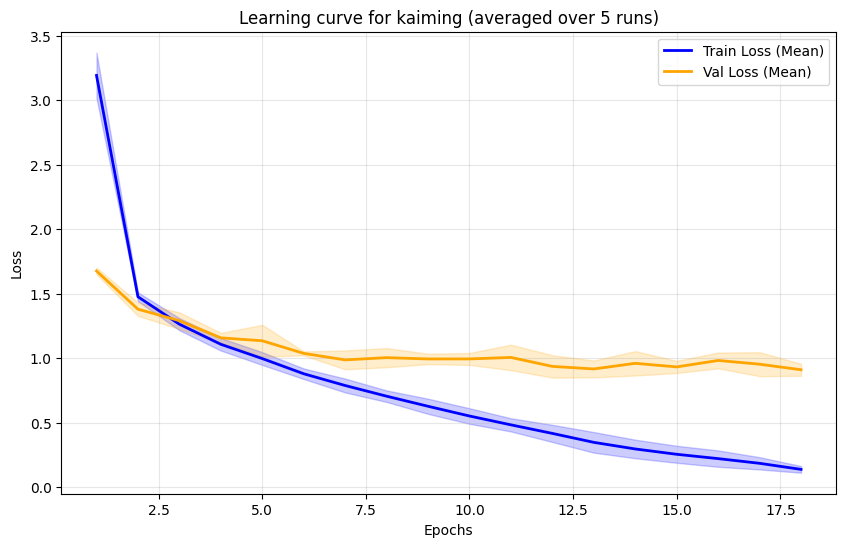

In [33]:
plot_strategy_comparison(RESULTS, 'kaiming')

This is the learning curve for truncated normal as the initialization strategy:

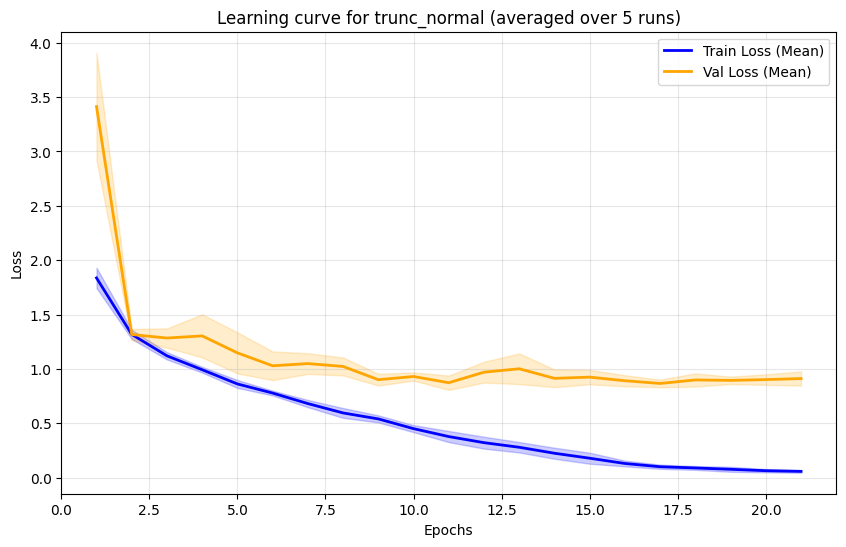

In [34]:
plot_strategy_comparison(RESULTS, 'trunc_normal')

What you can see in these plots:
- kaiming already has a lower validation loss in the beginning, but truncated normal converges quickly
- for both strategies, the validation loss quickly reaches a plateau
- the validation losses for truncated normal differ more from run to run than the validation losses for kaiming -> kaiming is more stable

Based on these results, I choose truncated normal as the initialization strategy for my model. Although it is more instable in respect to validation loss, it is more stable in respect to the evaluation metrics and performs a little better. 

I choose the fourth run of truncated normal for my final model. It has the highest precision for transparent plastic and the balanced accuracy isn't much lower than in the other runs. Also, the validation loss in this run is the lowest, indicating more confident and stable predictions. It's important to note that choosing the best run is a little bit of cherry-picking since it takes advantage of a "lucky" random initialization. But the low standard deviations show that there is consistent performance across all runs, so the best run isn't an extreme outlier.

In [35]:
results_df[results_df["init"] == "trunc_normal"][["init", "run", "balanced accuracy (test)", "precision transparent plastic (test)", "valid loss"]]

,init,run,balanced accuracy (test),precision transparent plastic (test),valid loss
5,trunc_normal,1,0.719492,0.732673,0.850663
6,trunc_normal,2,0.701188,0.755102,0.825495
7,trunc_normal,3,0.710708,0.737864,0.785326
8,trunc_normal,4,0.715836,0.770000,0.772264
9,trunc_normal,5,0.722165,0.732673,0.863339


In [36]:
final_model_run = [r for r in RESULTS if r['init'] == 'trunc_normal' and r['run'] == 5][0]
final_model = WasteCNN(NUM_CLASSES).to(DEVICE)
final_model.load_state_dict(final_model_run['best model state'])
final_model.eval()
_, _, y_final, y_pred_final=evaluate(model=final_model, data_loader=test_loader)

Here is the confusion matrix for my final model:

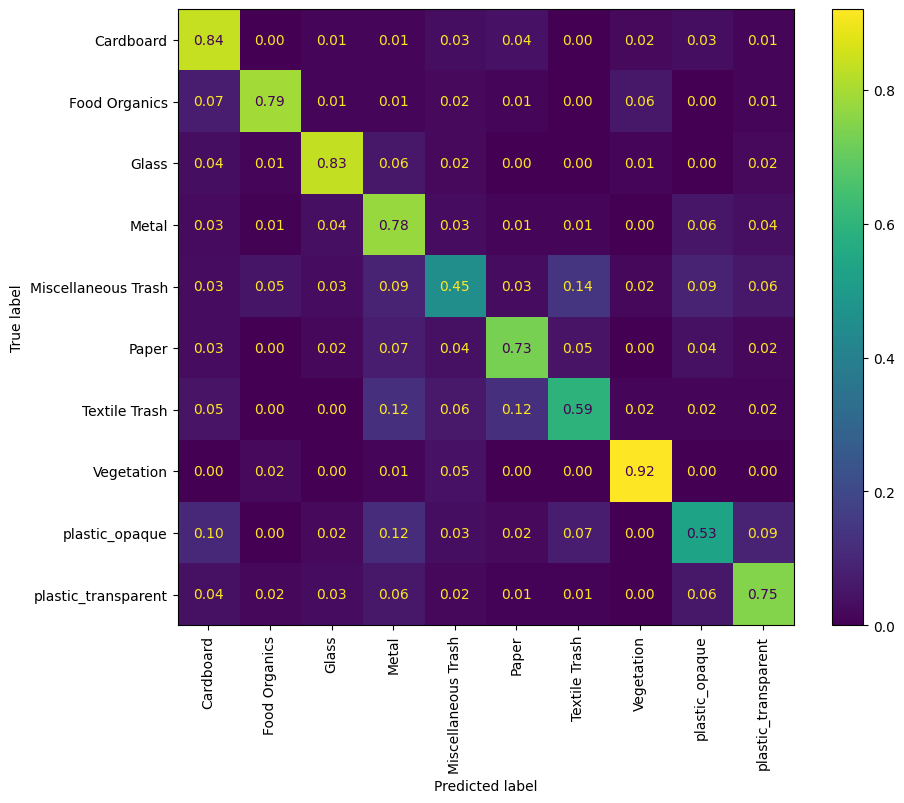

In [37]:
labels_df = pd.DataFrame(list(label_numbers.items()), columns=['Category', 'Target ID']).sort_values('Target ID')
class_names = labels_df['Category'].values

disp = ConfusionMatrixDisplay.from_predictions(
    y_final, 
    y_pred_final, 
    display_labels=class_names, 
    xticks_rotation=90, 
    normalize='true', #normalized -> recall values
    values_format='.2f')


fig = disp.figure_
fig.set_size_inches(10, 8)
plt.show()

What can you see in this matrix:
- The model is the best at classifying vegetation (92% of true vegetation images also classifies as vegetation)
- The model is better at classifying transparent plastic than classifying opaque plastic
- 9% of opaque plastic images get incorrectly classified as transparent plastic, 6% of transparent plastic images get incorrectly classified as opaque plastic
- Opaque plastic also gets confused with metal (12%) and cardboard (10%)
- Transparent plastics also gets confused with metal (6%), cardboard (4%) and glass (3%)
- The most common misclassification is miscellaneous trash which gets confused with textile trash (14% of miscellaneous trash images)
- Other common confusions: textile trash with metal (12%), textile trash with paper (12%)
- The model performs the worst on images of miscellaneous trash (only 45% correctly classified)

Here are some examples of misclassifications to get an impression with which kind of image the model struggles:

In [38]:
def show_confusion(target, pred):
    t_id, p_id = list(class_names).index(target), list(class_names).index(pred)
    idx = np.where((y_final == t_id) & (y_pred_final == p_id))[0][0]
    img = test_loader.dataset[idx][0].permute(1, 2, 0).numpy()
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"true: {target} | prediction: {pred}")
    plt.axis('off')

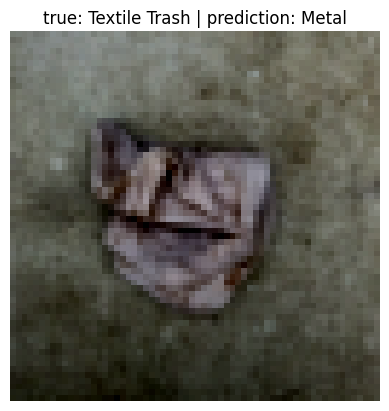

In [39]:
show_confusion('Textile Trash', 'Metal')

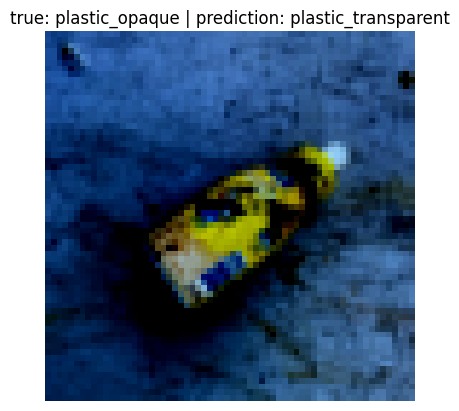

In [40]:
show_confusion('plastic_opaque', 'plastic_transparent')

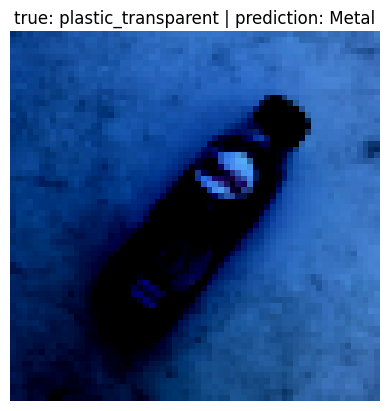

In [41]:
show_confusion('plastic_transparent', 'Metal')

## Task 7 - Conclusions and Future Work

### 1. Summary and Interpretation

- I implemented a CNN with three convolutional layers and ReLU as activation function
- I used CrossEntropyLoss as the loss function, Adam as the optimizer and implemented early stopping on the validation loss
- I tried three weight initialization stategies with 5 runs each: kaiming, truncated normal and constant initialization
- All strategies outperformed the baselines for balanced accuracy and precision for the transparent plastic class
- Constant performed the worst; it is not useful for a CNN
- Kaiming and truncated normal performed similarily with truncated normal yielding a little better and stable results
- Kaiming and truncated both showed high overfitting
- I chose a model with truncated normal initialization which reached a balanced accuracy of 0.7158 and a precision for transparent plastic of 0.77
- **The model isn't good enough for the use case**

### 2. Recommended course of action

- Don't use my model right now 
- Gather more data, especially on plastic types, that could be used for training a future model

### 3. Limitations and pitfalls when using my results

- My model showed high overfitting -> performance in the real context wouldn't be good enough 
- When using my model which was trained on 64x64 images in a real setting where the images have higher resolution, the performance could be even worse
- When using my model to differentiate between opaque and transparent plastic, you would trust my manual labelling which might contain errors

### 4. Three ideas for future work

- Apart from hyperparameter optimization:
1. Using a confidence threshold (e.g. 0.9) for classifying transparent plastic -> only classify if the model is *really* sure not just when it's the highest confidence among the classes -> could improve precision
2. Using only the waste categories where current classification actually falls short. For example, the current workflow at waste recovery facilities is good at identifying metal through magnets, so you could drop metal from the model
3. Augmenting the data before using it for the training

### 5. Discussion of employed methodology

- Using a CNN was a reasonable choice for the use case 
- I did the labelling of transparent and opaque plastic myself, without someone else validating my labelling. Just using "transparent" plastic as a category also isn't specific enough for the use case which would require a labelling based on polymer type for which I lack domain knowledge
- I think splitting the plastic images into transparent and opaque plastic images was a good idea and seemed to have worked to a certain degree
- I used a random guesser as baseline, while in my context it would be more reasonable to use the classification that is happening right now through human work and sensors as the baseline -> a CNN should outperform *that* and not random guessing
- I don't know if the value selection for learning and model hyperparameters was actually reasonable, it felt a little bit random at times
- 64x64 might have been too low as a pixel size -> chosen to limit the training time to a reasonable time
- I chose loss as early stopping metric but balanced accuracy and precision for evaluation (metric mismatch). I chose this to prevent overfitting and overconfidence but it could be that the lowest loss doesn't result in the best metric values or that the early stopping happened even though the metrics could still improve
- No hyperparameter tuning
- There was a lot of overfitting with kaiming and truncated normal. The patience for early stopping might have been too high or I should have implemented a minimum delta 
- The implementation of the scheduler seemed to have improved the training for both kaiming and truncated normal but could've also led to overfitting 

### 6. Reflection

- The pitched goal might have been a little bit too ambitious 
- Maybe I could've focused on a simpler goal e.g. binary classification of recyclable vs. non-recyclable waste